# Early Stopping + Loss History on SJAFFE

Trains five neural-net LDL models on the **SJAFFE** dataset with a uniform
recipe:

- max **2500** epochs (an upper bound — early stopping cuts it short),
- `LDLEarlyStopping(monitor='kl_divergence', patience=50)`, restoring
  best weights when triggered,
- `LossHistory` captures per-epoch training loss and validation KL,
- 80 / 20 train/test split (the test split doubles as the validation set
  for early-stopping signal).

For each model we plot training loss + validation KL on twin axes, then a
combined comparison and a final test-score table.


In [64]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from pyldl.utils import load_dataset, LDLEarlyStopping, LossHistory
from pyldl.algorithms import AA_BP, Duo_LDL, EDL_LDL, BEDL_LDL, SNEFY_LDL, SA_BFGS


E0000 00:00:1777259289.745011 2429919 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777259290.475448 2429919 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777259293.936024 2429919 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777259293.936064 2429919 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777259293.936066 2429919 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777259293.936068 2429919 computation_placer.cc:177] computation placer already registered. Please check linka

ImportError: cannot import name 'LossHistory' from 'pyldl.utils' (/project/6004619/dcs01/PyLDL/pyldl/utils.py)

## Load SJAFFE

In [56]:
X, D = load_dataset('Natural_Scene', dir='dataset')
X_train, X_test, D_train, D_test = train_test_split(X, D, test_size=0.2, random_state=0)
X_val, X_test, D_val, D_test = train_test_split(X_test, D_test, test_size=0.5, random_state=0)
print(f'X_train={X_train.shape}  D_train={D_train.shape}')
print(f'X_val  ={X_val.shape}    D_val  ={D_val.shape}')
print(f'X_test ={X_test.shape}   D_test ={D_test.shape}')


X_train=(1600, 294)  D_train=(1600, 9)
X_val  =(200, 294)    D_val  =(200, 9)
X_test =(200, 294)   D_test =(200, 9)


In [57]:
X_train.min(), X_train.max()

(0.0, 0.999969482)

## Training helper

`train_with_history` runs one model with the standard early-stopping +
loss-history callback pair and returns both the trained model and the
captured history.

`AA_BP` gets `AdamW(1e-2)` because its inherited default is
`SGD(1e-3)`, which converges far too slowly to see meaningful behaviour
inside 2500 epochs. The other four models inherit `Adam(1e-3)` from
`BaseAdam` and we leave that alone for an apples-to-apples comparison.


In [67]:
def train_with_history(name, model, **fit_kwargs):
    history = LossHistory()
    callbacks = [
        LDLEarlyStopping(monitor='kl_divergence', patience=100),
        history,
    ]
    print(f'--- training {name} ---')
    model.fit(
        X_train, D_train,
        epochs=2500, batch_size=64,
        X_val=X_val, D_val=D_val,
        callbacks=callbacks,
        **fit_kwargs,
    )
    n_epochs = len(history.history.get('loss', []))
    print(f'  finished after {n_epochs} epochs')
    return model, history


## Train each model

In [68]:
results = {}

learning_rate = 1e-3
weight_decay = 1e-4

results['AA_BP'] = train_with_history(
    'AA_BP', AA_BP(),
    optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
)
results['Duo_LDL']   = train_with_history('Duo_LDL',   Duo_LDL(n_hidden=64),
        optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay))
results['EDL_LDL']   = train_with_history('EDL_LDL',   EDL_LDL(n_hidden=64),
        optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay))
results['BEDL_LDL']  = train_with_history('BEDL_LDL',  BEDL_LDL(n_hidden=64),
        optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay))
results['EDL_LDL_bayes']   = train_with_history('EDL_LDL_bayes',   EDL_LDL(n_hidden=64),
        optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
        loss_type='bayes_mse')
results['BEDL_LDL_bayes']  = train_with_history('BEDL_LDL_bayes',  BEDL_LDL(n_hidden=64),
        optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
        loss_type='bayes_mse')
results['SNEFY_LDL'] = train_with_history('SNEFY_LDL', SNEFY_LDL(),
        optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay))


--- training AA_BP ---


KeyboardInterrupt: 

## Per-model loss curves

Training loss (blue, left axis) and validation KL divergence (red, right
axis) on twin axes. Early-stopping fires when the val-KL curve fails to
improve for 50 epochs; the model's final weights are restored to the
best-val-KL epoch.


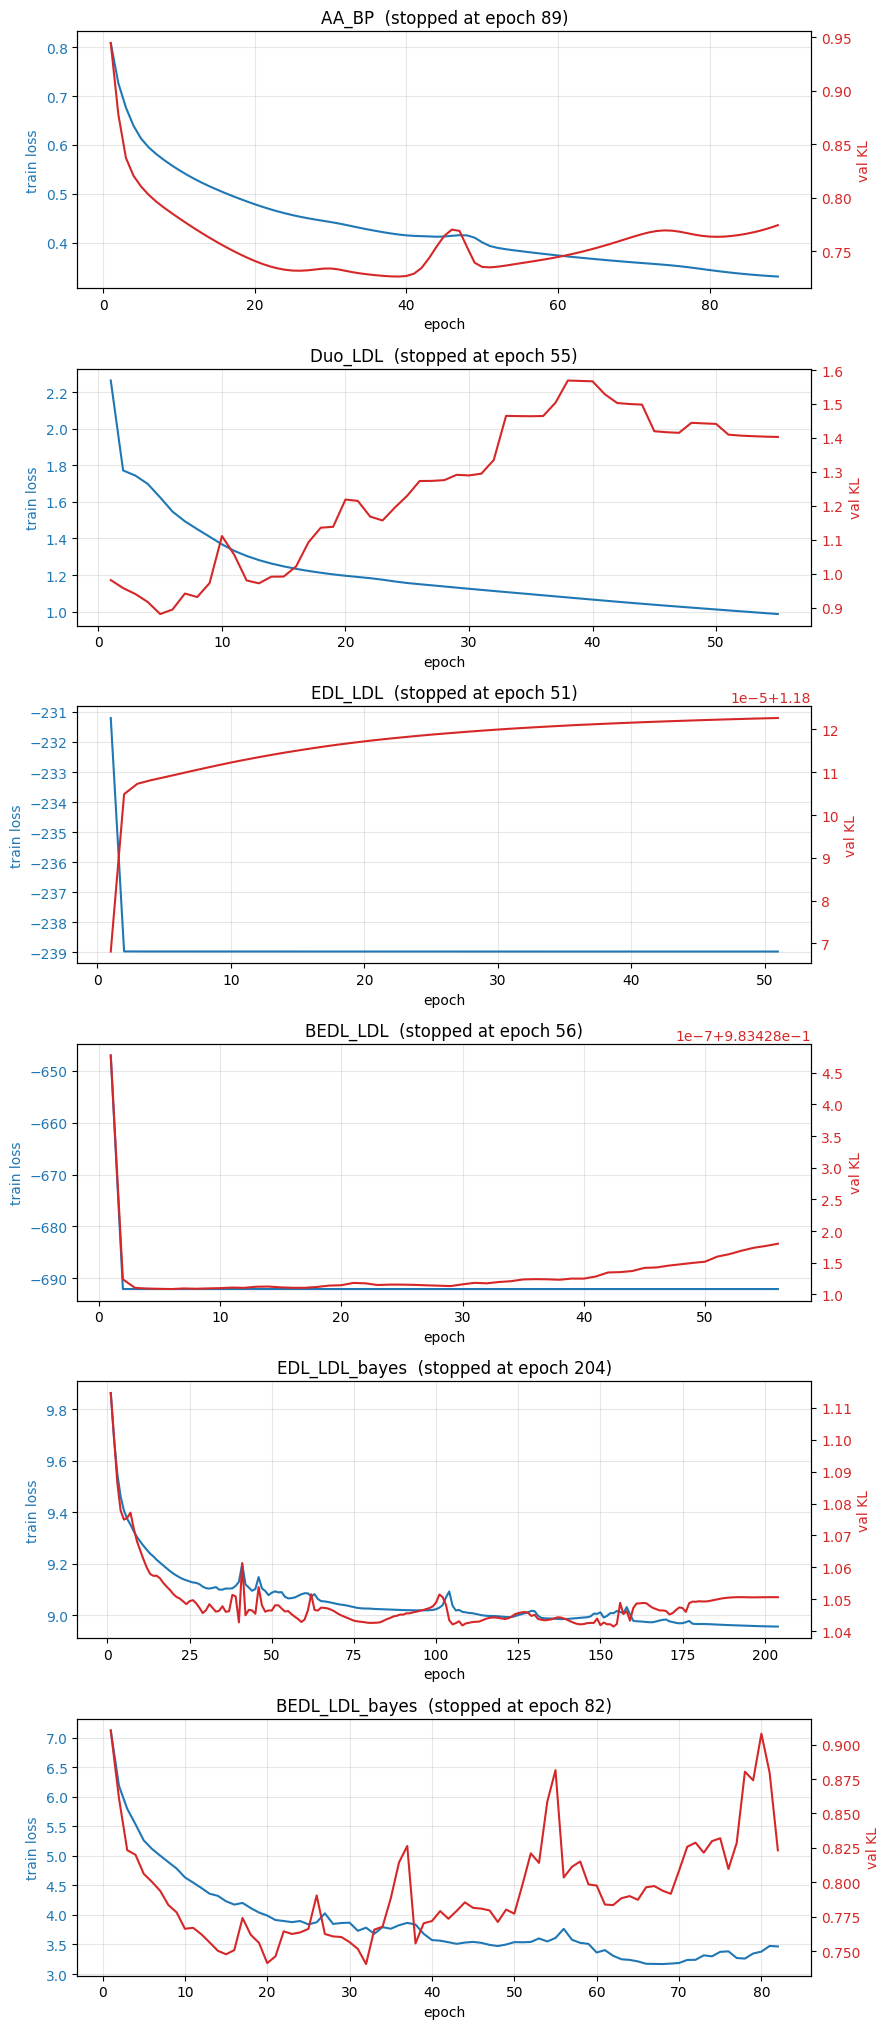

In [60]:
fig, axes = plt.subplots(len(results), 1, figsize=(9, 3.4 * len(results)), squeeze=False)

for ax_row, (name, (_, h)) in zip(axes, results.items()):
    ax = ax_row[0]
    ep = range(1, len(h.history['loss']) + 1)
    ax.plot(ep, h.history['loss'], color='C0', label='train loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('train loss', color='C0')
    ax.tick_params(axis='y', labelcolor='C0')

    ax2 = ax.twinx()
    ax2.plot(ep, h.history['kl_divergence'], color='C3', label='val KL')
    ax2.set_ylabel('val KL', color='C3')
    ax2.tick_params(axis='y', labelcolor='C3')

    ax.set_title(f'{name}  (stopped at epoch {len(ep)})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Validation KL comparison across models

All five val-KL curves on a single axis. Useful for seeing which models
converge faster vs. which reach a lower final KL.


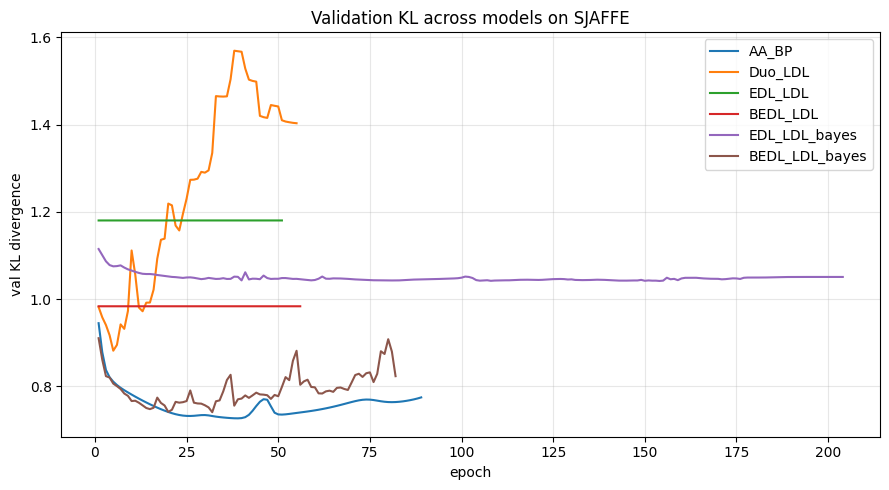

In [61]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, (_, h) in results.items():
    kl = h.history['kl_divergence']
    ax.plot(range(1, len(kl) + 1), kl, label=name)

ax.set_xlabel('epoch'); ax.set_ylabel('val KL divergence')
ax.set_title('Validation KL across models on SJAFFE')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Final test-set scores

Computed on `X_test` / `D_test` after early-stopping has restored each
model to its best-val-KL weights.


In [62]:
METRICS = ['chebyshev', 'clark', 'canberra', 'kl_divergence', 'cosine', 'intersection']

rows = []
for name, (model, h) in results.items():
    s = model.score(X_test, D_test, metrics=METRICS, return_dict=True)
    rows.append({
        'model': name,
        'epochs_run': len(h.history.get('loss', [])),
        **{k: float(v) for k, v in s.items()},
    })

scores_df = pd.DataFrame(rows).set_index('model')
scores_df


,epochs_run,chebyshev,clark,canberra,kl_divergence,cosine,intersection
model,,,,,,,
AA_BP,89,0.272703,2.424909,6.620263,0.658337,0.786677,0.615192
Duo_LDL,55,0.358102,2.484840,6.864395,0.908802,0.712073,0.479391
EDL_LDL,51,0.413248,2.509655,7.041422,1.221526,0.577496,0.376765
BEDL_LDL,56,0.385149,2.495977,6.903303,0.982805,0.661753,0.452409
EDL_LDL_bayes,204,0.379149,2.497260,7.005002,1.050133,0.651047,0.397873
BEDL_LDL_bayes,82,0.277420,2.404814,6.559648,0.656972,0.782223,0.619637


In [65]:
sa_bfgs_mod = SA_BFGS()
sa_bfgs_mod.fit(X_train, D_train)
scores = sa_bfgs_mod.score(X_test, D_test, return_dict=True)
print(f'--- {sa_bfgs_mod.__class__.__name__} ---')
for k, v in scores.items():
    print(f'{k}: {v:.4f}')

--- SA_BFGS ---
chebyshev: 0.3360
clark: 2.4399
canberra: 6.7402
kl_divergence: 0.8234
cosine: 0.7209
intersection: 0.5430
